# Refactored Hybrid Model: PhoBERT + TF-IDF Light Fusion\n\n## Design goals\n1. Keep PhoBERT close to the strong baseline by using the CLS token directly.\n2. Keep TF-IDF as a lightweight auxiliary lexical signal.\n3. Compare simple concatenation against optional gated fusion.\n4. Make class weighting and selection metrics easy to change.


## 1. Setup và Import Libraries

In [4]:
import os, sys, json, time, random, copy
from pathlib import Path
from datetime import datetime
from collections import Counter

IN_COLAB = False
try:
    from google.colab import drive  # type: ignore
    IN_COLAB = True
except ImportError:
    drive = None

if IN_COLAB:
    drive.mount('/content/drive')

def find_project_root():
    if IN_COLAB:
        root = Path('/content/drive/MyDrive/Student-Feedback-Sentiment-Analysis')
        if root.exists():
            return root
        raise FileNotFoundError(root)
    cwd = Path.cwd().resolve()
    for candidate in [cwd] + list(cwd.parents):
        if (candidate / 'src').exists() and (candidate / 'data').exists() and (candidate / 'results').exists():
            return candidate
    raise FileNotFoundError('Project root not found')

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
print(f'Project root: {PROJECT_ROOT}')

Mounted at /content/drive
Project root: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis


In [5]:
import joblib
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModel, get_linear_schedule_with_warmup
from sklearn.decomposition import TruncatedSVD
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, precision_score, recall_score, precision_recall_fscore_support
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from IPython.display import display
from tqdm.auto import tqdm
from src.data_utils import load_data, preprocess_vietnamese

plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('deep')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)
print(f'PyTorch: {torch.__version__}')
print(f'CUDA available: {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU: {torch.cuda.get_device_name(0)}')


PyTorch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


## 2. Configuration

In [6]:
class Config:
    BASE_DIR = str(PROJECT_ROOT)
    DATA_DIR = os.path.join(BASE_DIR, 'data', 'processed')
    MODEL_TYPE = 'PhoBERT_TFIDF_Refactored_LightFusion'
    EXPERIMENT_TYPE = 'improvements'
    TIMESTAMP = datetime.now().strftime('%Y%m%d_%H%M%S')
    RESULTS_DIR = os.path.join(BASE_DIR, 'results', MODEL_TYPE, EXPERIMENT_TYPE, TIMESTAMP)
    MODELS_DIR = os.path.join(RESULTS_DIR, 'models')
    SUMMARIES_DIR = os.path.join(RESULTS_DIR, 'summaries')
    VISUALIZATIONS_DIR = os.path.join(RESULTS_DIR, 'visualizations')
    ARTIFACTS_DIR = os.path.join(RESULTS_DIR, 'artifacts')
    MODEL_NAME = 'vinai/phobert-base'
    LABEL_MAP = {0: 'Negative', 1: 'Neutral', 2: 'Positive'}
    NUM_CLASSES = 3
    DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    MAX_LENGTH = 256
    BATCH_SIZE = 16
    EPOCHS = 15
    EARLY_STOP_PATIENCE = 3
    WARMUP_RATIO = 0.1
    GRADIENT_CLIP = 1.0
    WEIGHT_DECAY = 0.01
    DROPOUT = 0.3
    PHOBERT_LR_FROZEN = 0.0
    PHOBERT_LR_PARTIAL = 1e-5
    PHOBERT_LR_FULL = 2e-5
    HEAD_LR = 5e-5
    FREEZE_EPOCHS = 1
    PARTIAL_UNFREEZE_EPOCH = 2
    FULL_UNFREEZE_EPOCH = 4
    PARTIAL_UNFREEZE_LAST_N = 4
    TFIDF_MAX_FEATURES = 5000
    TFIDF_NGRAM_RANGE = (1, 2)
    TFIDF_MIN_DF = 3
    TFIDF_MAX_DF = 0.90
    TFIDF_SUBLINEAR_TF = True
    TFIDF_REDUCTION = 'lsa'  # Compare 'lsa' vs 'none'
    TFIDF_LSA_COMPONENTS = 256
    TFIDF_LSA_N_ITER = 10
    TFIDF_LSA_RANDOM_STATE = 42
    FUSION_MODE = 'concat'  # Change to 'gated' for an auxiliary gate
    TFIDF_PROJ_DIM = 96
    CLASSIFIER_HIDDEN_DIM = 256
    SELECTION_METRIC = 'f1_macro'
    CLASS_WEIGHT_MODE = 'sqrt_balanced'

config = Config()
for path in [config.RESULTS_DIR, config.MODELS_DIR, config.SUMMARIES_DIR, config.VISUALIZATIONS_DIR, config.ARTIFACTS_DIR]:
    os.makedirs(path, exist_ok=True)

assert config.FUSION_MODE in {'concat', 'gated'}
assert config.SELECTION_METRIC in {'f1_macro', 'f1_weighted'}
assert config.CLASS_WEIGHT_MODE in {'none', 'sqrt_balanced', 'log1p_balanced', 'balanced'}

print('=' * 60)
print('REFACTORED CONFIGURATION')
print('=' * 60)
print(f'Model: {config.MODEL_NAME}')
print(f'Fusion Mode: {config.FUSION_MODE}')
print(f'Selection Metric: {config.SELECTION_METRIC}')
print(f'Class Weight Mode: {config.CLASS_WEIGHT_MODE}')
print(f'TF-IDF Reduction: {config.TFIDF_REDUCTION}')
print(f'Batch Size: {config.BATCH_SIZE}')
print(f'Epochs: {config.EPOCHS}')
print(f'Device: {config.DEVICE}')
print(f'Results Dir: {config.RESULTS_DIR}')


REFACTORED CONFIGURATION
Model: vinai/phobert-base
Fusion Mode: concat
Selection Metric: f1_macro
Class Weight Mode: sqrt_balanced
TF-IDF Reduction: lsa
Batch Size: 16
Epochs: 15
Device: cuda
Results Dir: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TFIDF_Refactored_LightFusion/improvements/20260320_173649


## 3. Load Data

In [7]:
train_texts, train_labels = load_data(config.DATA_DIR, 'train')
val_texts, val_labels = load_data(config.DATA_DIR, 'validation')
test_texts, test_labels = load_data(config.DATA_DIR, 'test')

print('Label distribution:')
for split_name, labels in [('Train', train_labels), ('Validation', val_labels), ('Test', test_labels)]:
    counter = Counter(labels)
    print(f'{split_name}: total={len(labels)}')
    for idx, name in config.LABEL_MAP.items():
        count = counter.get(idx, 0)
        print(f'  {name}: {count} ({count/len(labels)*100:.1f}%)')

Label distribution:
Train: total=11426
  Negative: 5325 (46.6%)
  Neutral: 458 (4.0%)
  Positive: 5643 (49.4%)
Validation: total=1583
  Negative: 705 (44.5%)
  Neutral: 73 (4.6%)
  Positive: 805 (50.9%)
Test: total=3166
  Negative: 1409 (44.5%)
  Neutral: 167 (5.3%)
  Positive: 1590 (50.2%)


## 4. TF-IDF Feature Extraction


In [8]:
train_texts_processed = [preprocess_vietnamese(text) for text in train_texts]
val_texts_processed = [preprocess_vietnamese(text) for text in val_texts]
test_texts_processed = [preprocess_vietnamese(text) for text in test_texts]

tfidf_vectorizer = TfidfVectorizer(
    max_features=config.TFIDF_MAX_FEATURES,
    ngram_range=config.TFIDF_NGRAM_RANGE,
    min_df=config.TFIDF_MIN_DF,
    max_df=config.TFIDF_MAX_DF,
    sublinear_tf=config.TFIDF_SUBLINEAR_TF
)

train_tfidf_sparse = tfidf_vectorizer.fit_transform(train_texts_processed).astype(np.float32)
val_tfidf_sparse = tfidf_vectorizer.transform(val_texts_processed).astype(np.float32)
test_tfidf_sparse = tfidf_vectorizer.transform(test_texts_processed).astype(np.float32)

lsa_explained_variance = None
lsa_components_used = None
if config.TFIDF_REDUCTION == 'lsa':
    # LSA gives a compact lexical summary, but too much compression may remove useful cues.
    max_lsa_dim = max(1, min(train_tfidf_sparse.shape[0] - 1, train_tfidf_sparse.shape[1] - 1))
    effective_lsa_dim = min(config.TFIDF_LSA_COMPONENTS, max_lsa_dim)
    tfidf_lsa = TruncatedSVD(
        n_components=effective_lsa_dim,
        n_iter=config.TFIDF_LSA_N_ITER,
        random_state=config.TFIDF_LSA_RANDOM_STATE
    )
    train_tfidf_features = tfidf_lsa.fit_transform(train_tfidf_sparse).astype(np.float32)
    val_tfidf_features = tfidf_lsa.transform(val_tfidf_sparse).astype(np.float32)
    test_tfidf_features = tfidf_lsa.transform(test_tfidf_sparse).astype(np.float32)
    lsa_explained_variance = float(tfidf_lsa.explained_variance_ratio_.sum())
    lsa_components_used = int(train_tfidf_features.shape[1])
    joblib.dump(tfidf_lsa, os.path.join(config.ARTIFACTS_DIR, 'tfidf_lsa.pkl'))
else:
    # Skipping LSA preserves all lexical dimensions, but the auxiliary head becomes larger.
    train_tfidf_features = train_tfidf_sparse.toarray().astype(np.float32)
    val_tfidf_features = val_tfidf_sparse.toarray().astype(np.float32)
    test_tfidf_features = test_tfidf_sparse.toarray().astype(np.float32)

tfidf_scaler = StandardScaler()
train_tfidf = tfidf_scaler.fit_transform(train_tfidf_features).astype(np.float32)
val_tfidf = tfidf_scaler.transform(val_tfidf_features).astype(np.float32)
test_tfidf = tfidf_scaler.transform(test_tfidf_features).astype(np.float32)
tfidf_input_dim = int(train_tfidf.shape[1])

joblib.dump(tfidf_vectorizer, os.path.join(config.ARTIFACTS_DIR, 'tfidf_vectorizer.pkl'))
joblib.dump(tfidf_scaler, os.path.join(config.ARTIFACTS_DIR, 'tfidf_scaler.pkl'))

print(f'TF-IDF sparse shapes: Train={train_tfidf_sparse.shape}, Val={val_tfidf_sparse.shape}, Test={test_tfidf_sparse.shape}')
print(f'TF-IDF dense shapes: Train={train_tfidf.shape}, Val={val_tfidf.shape}, Test={test_tfidf.shape}')
if lsa_explained_variance is not None:
    print(f'LSA components used: {lsa_components_used}')
    print(f'LSA explained variance ratio sum: {lsa_explained_variance:.4f}')
else:
    print('LSA disabled: using original TF-IDF space before the lightweight projection head.')


TF-IDF sparse shapes: Train=(11426, 5000), Val=(1583, 5000), Test=(3166, 5000)
TF-IDF dense shapes: Train=(11426, 256), Val=(1583, 256), Test=(3166, 256)
LSA components used: 256
LSA explained variance ratio sum: 0.5020


## 5. Dataset & Model Definition


In [9]:
class HybridDataset(Dataset):
    """Dataset for PhoBERT text inputs plus lightweight TF-IDF features."""
    def __init__(self, texts, tfidf_features, labels, tokenizer, max_length):
        self.texts = texts
        self.tfidf_features = tfidf_features
        self.labels = labels
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = str(self.texts[idx])
        tfidf = np.asarray(self.tfidf_features[idx], dtype=np.float32).ravel()
        encoding = self.tokenizer(
            text,
            add_special_tokens=True,
            max_length=self.max_length,
            padding='max_length',
            truncation=True,
            return_tensors='pt'
        )
        return {
            'input_ids': encoding['input_ids'].flatten(),
            'attention_mask': encoding['attention_mask'].flatten(),
            'tfidf': torch.tensor(tfidf, dtype=torch.float),
            'label': torch.tensor(self.labels[idx], dtype=torch.long)
        }


In [10]:
class PhoBERTTFIDFLightHybrid(nn.Module):
    """PhoBERT-first hybrid with a small auxiliary TF-IDF branch."""
    def __init__(self, model_name, tfidf_dim, num_classes, fusion_mode='concat', dropout=0.3):
        super().__init__()
        self.phobert = AutoModel.from_pretrained(model_name)
        self.fusion_mode = fusion_mode
        phobert_dim = self.phobert.config.hidden_size
        self.phobert_dropout = nn.Dropout(dropout)
        self.tfidf_projection = nn.Sequential(
            nn.Linear(tfidf_dim, config.TFIDF_PROJ_DIM),
            nn.LayerNorm(config.TFIDF_PROJ_DIM),
            nn.SiLU(),
            nn.Dropout(dropout)
        )
        combined_dim = phobert_dim + config.TFIDF_PROJ_DIM
        if fusion_mode == 'gated':
            self.aux_gate = nn.Linear(combined_dim, config.TFIDF_PROJ_DIM)
            nn.init.constant_(self.aux_gate.bias, -1.0)
        else:
            self.aux_gate = None
        self.classifier = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(combined_dim, config.CLASSIFIER_HIDDEN_DIM),
            nn.SiLU(),
            nn.Dropout(dropout),
            nn.Linear(config.CLASSIFIER_HIDDEN_DIM, num_classes)
        )

    def get_head_modules(self):
        modules = [self.tfidf_projection, self.classifier]
        if self.aux_gate is not None:
            modules.append(self.aux_gate)
        return modules

    def forward(self, input_ids, attention_mask, tfidf_features):
        outputs = self.phobert(input_ids=input_ids, attention_mask=attention_mask)
        # Keep PhoBERT close to the baseline by using the native CLS representation directly.
        phobert_cls = self.phobert_dropout(outputs.last_hidden_state[:, 0, :])
        tfidf_proj = self.tfidf_projection(tfidf_features)
        if self.aux_gate is not None:
            gate = torch.sigmoid(self.aux_gate(torch.cat([phobert_cls, tfidf_proj], dim=1)))
            tfidf_proj = tfidf_proj * gate
        return self.classifier(torch.cat([phobert_cls, tfidf_proj], dim=1))


def count_trainable_params(model):
    return sum(p.numel() for p in model.parameters() if p.requires_grad)


tokenizer = AutoTokenizer.from_pretrained(config.MODEL_NAME)
model = PhoBERTTFIDFLightHybrid(
    model_name=config.MODEL_NAME,
    tfidf_dim=tfidf_input_dim,
    num_classes=config.NUM_CLASSES,
    fusion_mode=config.FUSION_MODE,
    dropout=config.DROPOUT
).to(config.DEVICE)

total_params = sum(p.numel() for p in model.parameters())
print(f'TF-IDF input dim to model: {tfidf_input_dim}')
print(f'Total parameters: {total_params:,}')
print(f'Initial trainable parameters: {count_trainable_params(model):,}')


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaModel LOAD REPORT from: vinai/phobert-base
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
lm_head.dense.bias              | UNEXPECTED |  | 
lm_head.layer_norm.bias         | UNEXPECTED |  | 
lm_head.layer_norm.weight       | UNEXPECTED |  | 
lm_head.bias                    | UNEXPECTED |  | 
lm_head.dense.weight            | UNEXPECTED |  | 
lm_head.decoder.weight          | UNEXPECTED |  | 
lm_head.decoder.bias            | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


TF-IDF input dim to model: 256
Total parameters: 135,245,347
Initial trainable parameters: 135,245,347


## 6. Create DataLoaders


In [11]:
train_dataset = HybridDataset(train_texts, train_tfidf.astype(np.float32), train_labels, tokenizer, config.MAX_LENGTH)
val_dataset = HybridDataset(val_texts, val_tfidf.astype(np.float32), val_labels, tokenizer, config.MAX_LENGTH)
test_dataset = HybridDataset(test_texts, test_tfidf.astype(np.float32), test_labels, tokenizer, config.MAX_LENGTH)
train_loader = DataLoader(train_dataset, batch_size=config.BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=config.BATCH_SIZE, shuffle=False)
print(f'TF-IDF dense feature dim: {tfidf_input_dim}')
print(f'Train batches: {len(train_loader)}')
print(f'Val batches: {len(val_loader)}')
print(f'Test batches: {len(test_loader)}')


TF-IDF dense feature dim: 256
Train batches: 715
Val batches: 99
Test batches: 198


## 7. Training Setup with Gradual Unfreezing


In [12]:
def build_class_weight_tensor(labels, mode, device):
    classes = np.array(sorted(set(labels)))
    balanced = compute_class_weight(class_weight='balanced', classes=classes, y=np.array(labels)).astype(np.float32)
    if mode == 'none':
        return None, balanced, None
    if mode == 'sqrt_balanced':
        applied = np.sqrt(balanced)
    elif mode == 'log1p_balanced':
        applied = np.log1p(balanced)
    elif mode == 'balanced':
        applied = balanced
    else:
        raise ValueError(f'Unsupported class weight mode: {mode}')
    return torch.tensor(applied, dtype=torch.float, device=device), balanced, applied


class_weights, raw_class_weights, applied_class_weights = build_class_weight_tensor(
    train_labels, config.CLASS_WEIGHT_MODE, config.DEVICE
)
criterion = nn.CrossEntropyLoss(weight=class_weights)
print(f'Raw balanced weights: {raw_class_weights.tolist()}')
if applied_class_weights is None:
    print('Class weight mode: none')
else:
    print(f'Applied class weights ({config.CLASS_WEIGHT_MODE}): {applied_class_weights.tolist()}')


def get_training_stage(epoch_number):
    if epoch_number <= config.FREEZE_EPOCHS:
        return 'frozen'
    if epoch_number < config.FULL_UNFREEZE_EPOCH:
        return 'partial'
    return 'full'


def set_phobert_trainable_layers(model, stage):
    for param in model.phobert.parameters():
        param.requires_grad = False
    if stage == 'partial':
        for layer in model.phobert.encoder.layer[-config.PARTIAL_UNFREEZE_LAST_N:]:
            for param in layer.parameters():
                param.requires_grad = True
    elif stage == 'full':
        for param in model.phobert.parameters():
            param.requires_grad = True
    for module in model.get_head_modules():
        for param in module.parameters():
            param.requires_grad = True


def build_optimizer_and_scheduler(model, stage, epoch_number):
    phobert_lr = {
        'frozen': config.PHOBERT_LR_FROZEN,
        'partial': config.PHOBERT_LR_PARTIAL,
        'full': config.PHOBERT_LR_FULL
    }[stage]
    groups = []
    phobert_params = [p for p in model.phobert.parameters() if p.requires_grad]
    if phobert_params:
        groups.append({'params': phobert_params, 'lr': phobert_lr})
    head_params = [p for module in model.get_head_modules() for p in module.parameters() if p.requires_grad]
    groups.append({'params': head_params, 'lr': config.HEAD_LR})
    optimizer = torch.optim.AdamW(groups, weight_decay=config.WEIGHT_DECAY)
    remaining_epochs = config.EPOCHS - epoch_number + 1
    total_steps = max(1, remaining_epochs * len(train_loader))
    warmup_steps = int(total_steps * config.WARMUP_RATIO)
    scheduler = get_linear_schedule_with_warmup(
        optimizer,
        num_warmup_steps=warmup_steps,
        num_training_steps=total_steps
    )
    return optimizer, scheduler, phobert_lr


def get_selection_score(metrics):
    return metrics[config.SELECTION_METRIC]


set_phobert_trainable_layers(model, 'frozen')
print(f'Trainable params after freeze: {count_trainable_params(model):,}')


Raw balanced weights: [0.7152425646781921, 8.315866470336914, 0.6749364733695984]
Applied class weights (sqrt_balanced): [0.8457201719284058, 2.8837244510650635, 0.8215451836585999]
Trainable params after freeze: 247,075


## 8. Training Loop


In [13]:
def train_epoch(model, dataloader, criterion, optimizer, scheduler, device):
    model.train()
    total_loss = 0.0
    all_preds, all_labels = [], []
    for batch in tqdm(dataloader, desc='Training', leave=False):
        optimizer.zero_grad()
        input_ids = batch['input_ids'].to(device)
        attention_mask = batch['attention_mask'].to(device)
        tfidf = batch['tfidf'].to(device)
        labels = batch['label'].to(device)
        logits = model(input_ids, attention_mask, tfidf)
        loss = criterion(logits, labels)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), config.GRADIENT_CLIP)
        optimizer.step()
        scheduler.step()
        total_loss += loss.item()
        preds = torch.argmax(logits, dim=1)
        all_preds.extend(preds.detach().cpu().numpy())
        all_labels.extend(labels.detach().cpu().numpy())
    return {
        'loss': total_loss / len(dataloader),
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
    }


def evaluate(model, dataloader, criterion, device):
    model.eval()
    total_loss = 0.0
    all_preds, all_labels = [], []
    with torch.no_grad():
        for batch in tqdm(dataloader, desc='Evaluating', leave=False):
            input_ids = batch['input_ids'].to(device)
            attention_mask = batch['attention_mask'].to(device)
            tfidf = batch['tfidf'].to(device)
            labels = batch['label'].to(device)
            logits = model(input_ids, attention_mask, tfidf)
            loss = criterion(logits, labels)
            total_loss += loss.item()
            preds = torch.argmax(logits, dim=1)
            all_preds.extend(preds.detach().cpu().numpy())
            all_labels.extend(labels.detach().cpu().numpy())
    precision_pc, recall_pc, f1_pc, support_pc = precision_recall_fscore_support(
        all_labels, all_preds, labels=[0, 1, 2], zero_division=0
    )
    return {
        'loss': total_loss / len(dataloader),
        'accuracy': accuracy_score(all_labels, all_preds),
        'precision_macro': precision_score(all_labels, all_preds, average='macro', zero_division=0),
        'recall_macro': recall_score(all_labels, all_preds, average='macro', zero_division=0),
        'precision_weighted': precision_score(all_labels, all_preds, average='weighted', zero_division=0),
        'recall_weighted': recall_score(all_labels, all_preds, average='weighted', zero_division=0),
        'f1_macro': f1_score(all_labels, all_preds, average='macro', zero_division=0),
        'f1_weighted': f1_score(all_labels, all_preds, average='weighted', zero_division=0),
        'precision_per_class': precision_pc.tolist(),
        'recall_per_class': recall_pc.tolist(),
        'f1_per_class': f1_pc.tolist(),
        'support_per_class': support_pc.tolist(),
        'confusion_matrix': confusion_matrix(all_labels, all_preds, labels=[0, 1, 2]).tolist(),
        'classification_report_text': classification_report(all_labels, all_preds, labels=[0, 1, 2], target_names=list(config.LABEL_MAP.values()), zero_division=0),
        'y_pred': list(map(int, all_preds)),
        'y_true': list(map(int, all_labels)),
    }

def print_split_metrics(split_name, metrics):
    print(f'{split_name} Metrics:')
    print(f'  Accuracy: {metrics["accuracy"]:.4f}')
    print(f'  Precision Macro: {metrics["precision_macro"]:.4f}')
    print(f'  Recall Macro: {metrics["recall_macro"]:.4f}')
    print(f'  F1 Macro: {metrics["f1_macro"]:.4f}')
    print(f'  Precision Weighted: {metrics["precision_weighted"]:.4f}')
    print(f'  Recall Weighted: {metrics["recall_weighted"]:.4f}')
    print(f'  F1 Weighted: {metrics["f1_weighted"]:.4f}')
    print('Classification Report:')
    print(metrics['classification_report_text'])
    print('Confusion Matrix:')
    print(np.array(metrics['confusion_matrix']))


In [14]:
history = {
    'epoch': [], 'stage': [],
    'train_loss': [], 'train_acc': [], 'train_f1_macro': [], 'train_f1_weighted': [],
    'val_loss': [], 'val_acc': [], 'val_f1_macro': [], 'val_f1_weighted': [],
    'val_f1_neutral': [], 'val_selection_score': [], 'phobert_lr': [], 'trainable_params': []
}

best_val_score = -1.0
best_val_f1 = -1.0
best_epoch = 0
best_stage = None
best_model_state = None
patience_counter = 0
current_stage = None

print('=' * 70)
print('START TRAINING WITH GRADUAL UNFREEZING')
print('=' * 70)

for epoch in range(1, config.EPOCHS + 1):
    stage = get_training_stage(epoch)
    if stage != current_stage:
        current_stage = stage
        set_phobert_trainable_layers(model, stage)
        optimizer, scheduler, phobert_lr = build_optimizer_and_scheduler(model, stage, epoch)
        print(f'\n[Stage Switch] epoch={epoch} stage={stage} phobert_lr={phobert_lr} trainable_params={count_trainable_params(model):,}')

    print(f'\nEpoch {epoch}/{config.EPOCHS}')
    train_metrics = train_epoch(model, train_loader, criterion, optimizer, scheduler, config.DEVICE)
    val_metrics = evaluate(model, val_loader, criterion, config.DEVICE)
    selection_score = get_selection_score(val_metrics)

    history['epoch'].append(epoch)
    history['stage'].append(stage)
    history['train_loss'].append(train_metrics['loss'])
    history['train_acc'].append(train_metrics['accuracy'])
    history['train_f1_macro'].append(train_metrics['f1_macro'])
    history['train_f1_weighted'].append(train_metrics['f1_weighted'])
    history['val_loss'].append(val_metrics['loss'])
    history['val_acc'].append(val_metrics['accuracy'])
    history['val_f1_macro'].append(val_metrics['f1_macro'])
    history['val_f1_weighted'].append(val_metrics['f1_weighted'])
    history['val_f1_neutral'].append(val_metrics['f1_per_class'][1])
    history['val_selection_score'].append(selection_score)
    history['phobert_lr'].append(phobert_lr)
    history['trainable_params'].append(count_trainable_params(model))

    print(f"Train  - loss={train_metrics['loss']:.4f} acc={train_metrics['accuracy']:.4f} f1_macro={train_metrics['f1_macro']:.4f} f1_weighted={train_metrics['f1_weighted']:.4f}")
    print(f"Val    - loss={val_metrics['loss']:.4f} acc={val_metrics['accuracy']:.4f} f1_macro={val_metrics['f1_macro']:.4f} f1_weighted={val_metrics['f1_weighted']:.4f} f1_neutral={val_metrics['f1_per_class'][1]:.4f} selected={selection_score:.4f}")

    if selection_score > best_val_score:
        best_val_score = selection_score
        best_val_f1 = val_metrics['f1_macro']
        best_epoch = epoch
        best_stage = stage
        best_model_state = copy.deepcopy(model.state_dict())
        patience_counter = 0
        torch.save(best_model_state, os.path.join(config.MODELS_DIR, 'best_model.pt'))
        print(f'  -> New best model saved ({config.SELECTION_METRIC}={best_val_score:.4f})')
    else:
        patience_counter += 1
        print(f'  -> No improvement, patience={patience_counter}/{config.EARLY_STOP_PATIENCE}')
        if patience_counter >= config.EARLY_STOP_PATIENCE:
            print(f'  -> Early stopping at epoch {epoch}')
            break

assert best_model_state is not None
model.load_state_dict(best_model_state)
history_df = pd.DataFrame(history)
history_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'training_history.csv'), index=False)
print(f'\nBest epoch: {best_epoch}, best stage: {best_stage}, best {config.SELECTION_METRIC}: {best_val_score:.4f}, best val macro F1: {best_val_f1:.4f}')


START TRAINING WITH GRADUAL UNFREEZING

[Stage Switch] epoch=1 stage=frozen phobert_lr=0.0 trainable_params=247,075

Epoch 1/15


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.9795 acc=0.5621 f1_macro=0.4254 f1_weighted=0.5726
Val    - loss=0.8445 acc=0.8035 f1_macro=0.5477 f1_weighted=0.7848 f1_neutral=0.0000 selected=0.5477
  -> New best model saved (f1_macro=0.5477)

[Stage Switch] epoch=2 stage=partial phobert_lr=1e-05 trainable_params=28,598,563

Epoch 2/15


Training:   0%|          | 0/715 [00:00<?, ?it/s]

...

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0552 acc=0.9892 f1_macro=0.9755 f1_weighted=0.9892
Val    - loss=0.7216 acc=0.9387 f1_macro=0.8367 f1_weighted=0.9369 f1_neutral=0.6047 selected=0.8367
  -> No improvement, patience=2/3

Epoch 11/15


Training:   0%|          | 0/715 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Train  - loss=0.0400 acc=0.9928 f1_macro=0.9847 f1_weighted=0.9928
Val    - loss=0.7443 acc=0.9375 f1_macro=0.8350 f1_weighted=0.9361 f1_neutral=0.6015 selected=0.8350
  -> No improvement, patience=3/3
  -> Early stopping at epoch 11

Best epoch: 8, best stage: full, best f1_macro: 0.8538, best val macro F1: 0.8538


## 9. Evaluation on Validation and Test Sets


In [15]:
val_results = evaluate(model, val_loader, criterion, config.DEVICE)
test_results = evaluate(model, test_loader, criterion, config.DEVICE)
print_split_metrics('Validation', val_results)
print()
print_split_metrics('Test', test_results)


Evaluating:   0%|          | 0/99 [00:00<?, ?it/s]

Evaluating:   0%|          | 0/198 [00:00<?, ?it/s]

Validation Metrics:
  Accuracy: 0.9457
  Precision Macro: 0.8879
  Recall Macro: 0.8296
  F1 Macro: 0.8538
  Precision Weighted: 0.9434
  Recall Weighted: 0.9457
  F1 Weighted: 0.9438
Classification Report:
              precision    recall  f1-score   support

    Negative       0.95      0.95      0.95       705
     Neutral       0.76      0.56      0.65        73
    Positive       0.95      0.97      0.96       805

    accuracy                           0.95      1583
   macro avg       0.89      0.83      0.85      1583
weighted avg       0.94      0.95      0.94      1583

Confusion Matrix:
[[673   9  23]
 [ 16  41  16]
 [ 18   4 783]]

Test Metrics:
  Accuracy: 0.9327
  Precision Macro: 0.8698
  Recall Macro: 0.7947
  F1 Macro: 0.8226
  Precision Weighted: 0.9288
  Recall Weighted: 0.9327
  F1 Weighted: 0.9291
Classification Report:
              precision    recall  f1-score   support

    Negative       0.94      0.96      0.95      1409
     Neutral       0.73      0.47    

## 10. Save Results


In [16]:
summary_df = pd.DataFrame([
    {'Split': 'Validation', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage, 'Selection_Metric': config.SELECTION_METRIC, 'Selection_Score': best_val_score, 'Accuracy': val_results['accuracy'], 'Precision_Macro': val_results['precision_macro'], 'Recall_Macro': val_results['recall_macro'], 'F1_Macro': val_results['f1_macro'], 'F1_Weighted': val_results['f1_weighted'], 'F1_Negative': val_results['f1_per_class'][0], 'F1_Neutral': val_results['f1_per_class'][1], 'F1_Positive': val_results['f1_per_class'][2]},
    {'Split': 'Test', 'Best_Epoch': best_epoch, 'Best_Stage': best_stage, 'Selection_Metric': config.SELECTION_METRIC, 'Selection_Score': best_val_score, 'Accuracy': test_results['accuracy'], 'Precision_Macro': test_results['precision_macro'], 'Recall_Macro': test_results['recall_macro'], 'F1_Macro': test_results['f1_macro'], 'F1_Weighted': test_results['f1_weighted'], 'F1_Negative': test_results['f1_per_class'][0], 'F1_Neutral': test_results['f1_per_class'][1], 'F1_Positive': test_results['f1_per_class'][2]},
])
display(summary_df)
summary_df.to_csv(os.path.join(config.SUMMARIES_DIR, 'summary.csv'), index=False)

experiment_summary = {
    'model_type': config.MODEL_TYPE,
    'selection_metric': config.SELECTION_METRIC,
    'best_selection_score': best_val_score,
    'best_val_f1_macro': best_val_f1,
    'class_weight_mode': config.CLASS_WEIGHT_MODE,
    'class_weights_raw': raw_class_weights.tolist(),
    'class_weights_applied': None if applied_class_weights is None else applied_class_weights.tolist(),
    'fusion_mode': config.FUSION_MODE,
    'tfidf_reduction': config.TFIDF_REDUCTION,
    'tfidf_input_dim': tfidf_input_dim,
    'lsa_components_used': lsa_components_used,
    'lsa_explained_variance': lsa_explained_variance,
    'validation': val_results,
    'test': test_results,
}
with open(os.path.join(config.SUMMARIES_DIR, 'experiment_summary.json'), 'w', encoding='utf-8') as f:
    json.dump(experiment_summary, f, ensure_ascii=False, indent=2)

with open(os.path.join(config.SUMMARIES_DIR, 'training_results.txt'), 'w', encoding='utf-8') as f:
    f.write('=' * 60 + '\n')
    f.write('TRAINING RESULTS - PhoBERT + TF-IDF Refactored Light Fusion\n')
    f.write('=' * 60 + '\n')
    f.write(f'Best Epoch: {best_epoch}\n')
    f.write(f'Best Stage: {best_stage}\n')
    f.write(f'Selection Metric: {config.SELECTION_METRIC}\n')
    f.write(f'Best Selection Score: {best_val_score:.4f}\n')
    f.write(f'Fusion Mode: {config.FUSION_MODE}\n')
    f.write(f'Class Weight Mode: {config.CLASS_WEIGHT_MODE}\n')
    f.write(f'Test Accuracy: {test_results["accuracy"]:.4f}\n')
    f.write(f'Test Precision Macro: {test_results["precision_macro"]:.4f}\n')
    f.write(f'Test Recall Macro: {test_results["recall_macro"]:.4f}\n')
    f.write(f'Test F1 Macro: {test_results["f1_macro"]:.4f}\n')
    f.write(f'Test F1 Weighted: {test_results["f1_weighted"]:.4f}\n')

print(f'Saved outputs to: {config.RESULTS_DIR}')


,Split,Best_Epoch,Best_Stage,Selection_Metric,Selection_Score,Accuracy,Precision_Macro,Recall_Macro,F1_Macro,F1_Weighted,F1_Negative,F1_Neutral,F1_Positive
0,Validation,8,full,f1_macro,0.853812,0.945673,0.887908,0.829642,0.853812,0.943777,0.953258,0.645669,0.962508
1,Test,8,full,f1_macro,0.853812,0.932723,0.869758,0.794663,0.822583,0.929126,0.949894,0.569343,0.948511


Saved outputs to: /content/drive/MyDrive/Student-Feedback-Sentiment-Analysis/results/PhoBERT_TFIDF_Refactored_LightFusion/improvements/20260320_173649


## 11. Visualization


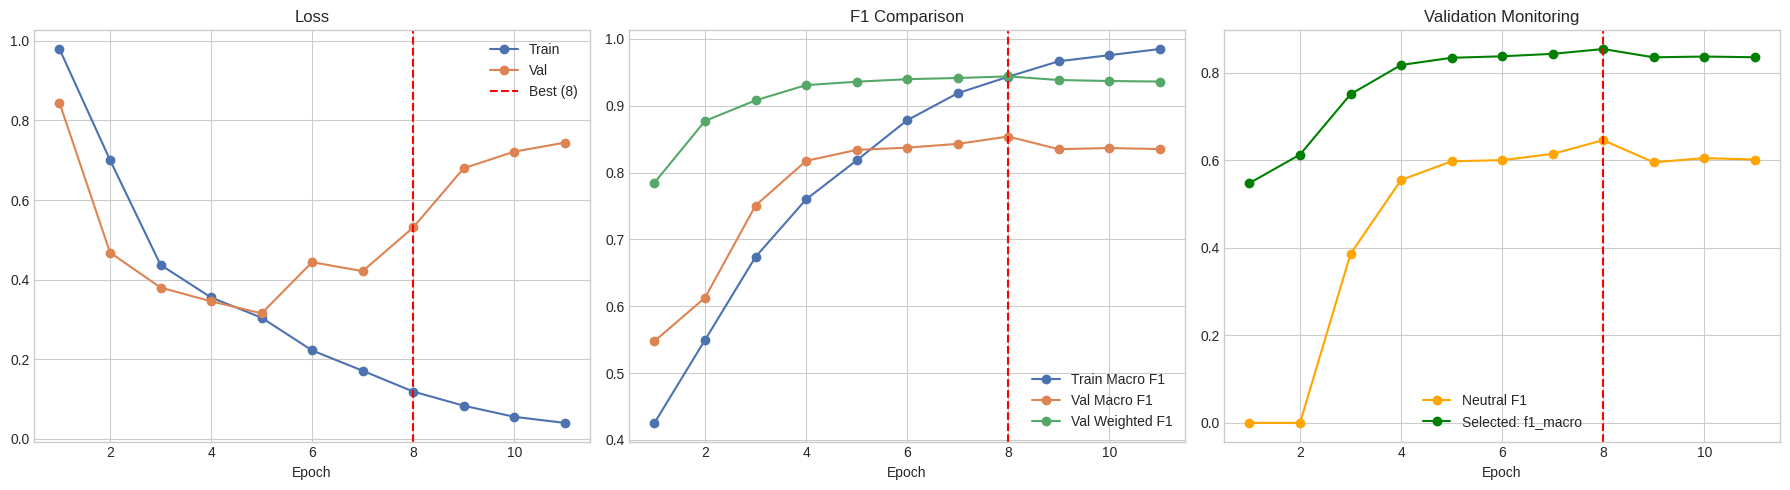

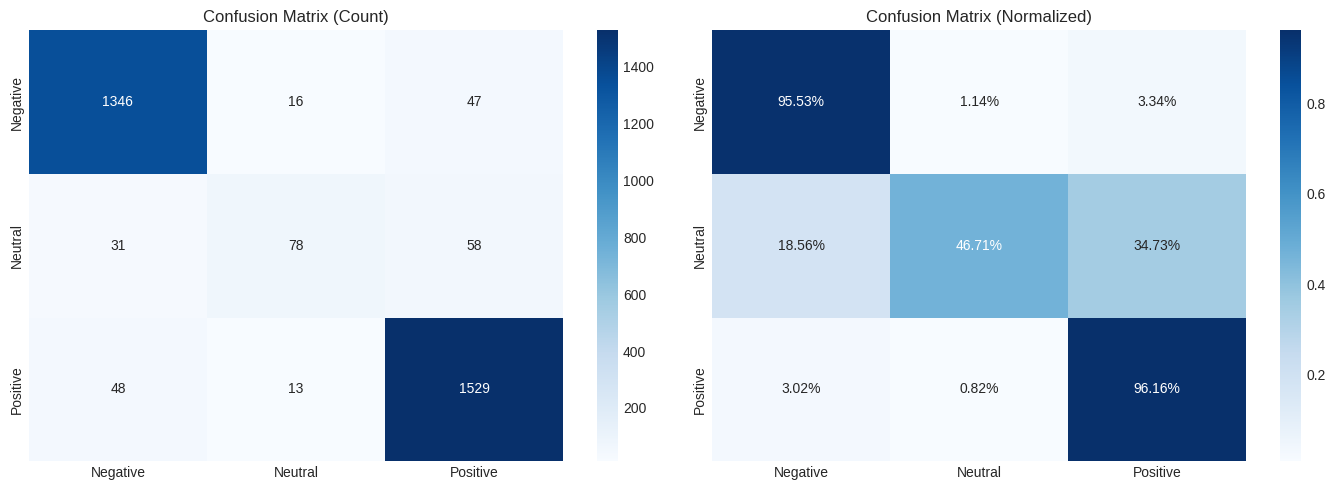

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
axes[0].plot(history_df['epoch'], history_df['train_loss'], marker='o', label='Train')
axes[0].plot(history_df['epoch'], history_df['val_loss'], marker='o', label='Val')
axes[0].axvline(best_epoch, color='red', linestyle='--', label=f'Best ({best_epoch})')
axes[0].set_title('Loss')
axes[0].set_xlabel('Epoch')
axes[0].legend()

axes[1].plot(history_df['epoch'], history_df['train_f1_macro'], marker='o', label='Train Macro F1')
axes[1].plot(history_df['epoch'], history_df['val_f1_macro'], marker='o', label='Val Macro F1')
axes[1].plot(history_df['epoch'], history_df['val_f1_weighted'], marker='o', label='Val Weighted F1')
axes[1].axvline(best_epoch, color='red', linestyle='--')
axes[1].set_title('F1 Comparison')
axes[1].set_xlabel('Epoch')
axes[1].legend()

axes[2].plot(history_df['epoch'], history_df['val_f1_neutral'], marker='o', color='orange', label='Neutral F1')
axes[2].plot(history_df['epoch'], history_df['val_selection_score'], marker='o', color='green', label=f'Selected: {config.SELECTION_METRIC}')
axes[2].axvline(best_epoch, color='red', linestyle='--')
axes[2].set_title('Validation Monitoring')
axes[2].set_xlabel('Epoch')
axes[2].legend()

plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'training_history.png'), dpi=150, bbox_inches='tight')
plt.show()

cm = np.array(test_results['confusion_matrix'])
row_sums = cm.sum(axis=1, keepdims=True)
cm_norm = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[0])
axes[0].set_title('Confusion Matrix (Count)')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=list(config.LABEL_MAP.values()), yticklabels=list(config.LABEL_MAP.values()), ax=axes[1])
axes[1].set_title('Confusion Matrix (Normalized)')
plt.tight_layout()
plt.savefig(os.path.join(config.VISUALIZATIONS_DIR, 'confusion_matrix.png'), dpi=150, bbox_inches='tight')
plt.show()


## 12. Error Analysis for Neutral Class


In [18]:
# Find misclassified Neutral samples
neutral_indices = [i for i, label in enumerate(test_results['y_true']) if label == 1]
misclassified_neutral = [
    (i, test_results['y_pred'][i], test_texts[i])
    for i in neutral_indices
    if test_results['y_pred'][i] != 1
]

print(f'Total Neutral samples: {len(neutral_indices)}')
print(f'Misclassified Neutral: {len(misclassified_neutral)}')
print(f'Neutral accuracy: {1 - len(misclassified_neutral)/len(neutral_indices):.2%}')

print('\n--- Sample Misclassified Neutral Feedback ---')
for idx, pred, text in misclassified_neutral[:10]:
    pred_label = config.LABEL_MAP[pred]
    print(f'  Predicted: {pred_label} | Text: "{text[:80]}..."' if len(text) > 80 else f'  Predicted: {pred_label} | Text: "{text}"')

# Count which classes Neutral is confused with
from collections import Counter
confusion_targets = Counter([pred for _, pred, _ in misclassified_neutral])
print(f'\nNeutral confusion targets:')
for cls, count in sorted(confusion_targets.items()):
    print(f'  {config.LABEL_MAP[cls]}: {count}')

Total Neutral samples: 167
Misclassified Neutral: 89
Neutral accuracy: 46.71%

--- Sample Misclassified Neutral Feedback ---
  Predicted: Positive | Text: "môn học này giúp chúng em hiểu ra những vấn đề cơ bản"
  Predicted: Negative | Text: "như vậy tụi em sẽ định hướng tốt hơn và tập trung vào những thứ cần thiết"
  Predicted: Positive | Text: "ví dụ phù hợp với nội dung kiến thức hướng dẫn chị tiết"
  Predicted: Positive | Text: "kỹ những chương cuối"
  Predicted: Positive | Text: "cô cho em 10 điểm thực hành colonlove"
  Predicted: Positive | Text: "có kết hợp với bài tập ví dụ"
  Predicted: Positive | Text: "bài tập đầy đủ"
  Predicted: Positive | Text: "có cung cấp tài liệu cho sinh viên"
  Predicted: Positive | Text: "ngoài ra còn nhiều kiến thức ngoài"
  Predicted: Positive | Text: "có demo trực tiếp"

Neutral confusion targets:
  Negative: 31
  Positive: 58


## What was changed

- Replaced positional encoding and mean pooling with the native PhoBERT CLS representation: `outputs.last_hidden_state[:, 0, :]`.
- Replaced the heavier hybrid heads with a lightweight auxiliary projection plus `concat` or optional `gated` fusion.
- Made class-weight handling configurable with `none`, `sqrt_balanced`, `log1p_balanced`, and `balanced`.
- Made best-model selection configurable between `f1_macro` and `f1_weighted`.
- Kept the evaluation, confusion matrix, per-class report, and neutral-class analysis sections runnable.


## Why these changes were made

- PhoBERT is the strongest semantic encoder in these notebooks, so the hybrid branch should support it rather than distort it.
- A small auxiliary branch keeps TF-IDF or SentiWordNet useful without letting those features dominate the model.
- Softer class weights are safer for the rare Neutral class and easier to compare in ablations.
- Clearer metric selection makes experiments more reproducible and easier to interpret.


## 13. Final Summary


In [19]:
print('=' * 70)
print('PHOBERT + TF-IDF REFACTORED LIGHT FUSION - FINAL SUMMARY')
print('=' * 70)
print('\nArchitecture Choices:')
print('  1. PhoBERT sentence representation uses outputs.last_hidden_state[:, 0, :]')
print('  2. No external positional encoding and no mean pooling')
print(f'  3. Lightweight TF-IDF auxiliary branch with fusion mode: {config.FUSION_MODE}')
print(f'  4. TF-IDF reduction mode: {config.TFIDF_REDUCTION}')
print(f'  5. Small classifier head with hidden dim {config.CLASSIFIER_HIDDEN_DIM}')
print(f'  6. Class weight mode: {config.CLASS_WEIGHT_MODE}')
print(f'\nBest epoch: {best_epoch}')
print(f'Best stage: {best_stage}')
print(f'Best {config.SELECTION_METRIC}: {best_val_score:.4f}')
print(f'Best val macro F1: {best_val_f1:.4f}')
print('\nTest Results:')
print(f'  Accuracy: {test_results["accuracy"]:.4f}')
print(f'  Precision Macro: {test_results["precision_macro"]:.4f}')
print(f'  Recall Macro: {test_results["recall_macro"]:.4f}')
print(f'  F1 Macro: {test_results["f1_macro"]:.4f}')
print(f'  F1 Weighted: {test_results["f1_weighted"]:.4f}')
print('\nConfusion Matrix:')
print(np.array(test_results['confusion_matrix']))
print('\n' + '=' * 70)


PHOBERT + TF-IDF REFACTORED LIGHT FUSION - FINAL SUMMARY

Architecture Choices:
  1. PhoBERT sentence representation uses outputs.last_hidden_state[:, 0, :]
  2. No external positional encoding and no mean pooling
  3. Lightweight TF-IDF auxiliary branch with fusion mode: concat
  4. TF-IDF reduction mode: lsa
  5. Small classifier head with hidden dim 256
  6. Class weight mode: sqrt_balanced

Best epoch: 8
Best stage: full
Best f1_macro: 0.8538
Best val macro F1: 0.8538

Test Results:
  Accuracy: 0.9327
  Precision Macro: 0.8698
  Recall Macro: 0.7947
  F1 Macro: 0.8226
  F1 Weighted: 0.9291

Confusion Matrix:
[[1346   16   47]
 [  31   78   58]
 [  48   13 1529]]



## Recommended next experiments

- Compare `FUSION_MODE = 'concat'` against `FUSION_MODE = 'gated'`.
- Compare `TFIDF_REDUCTION = 'lsa'` against `TFIDF_REDUCTION = 'none'`.
- Try `TFIDF_LSA_COMPONENTS` values such as `128`, `256`, and `384`.
- Compare `CLASS_WEIGHT_MODE = 'none'`, `'sqrt_balanced'`, and `'balanced'`.
- Compare `SELECTION_METRIC = 'f1_macro'` versus `'f1_weighted'`.
